## Mood Maker 코드 최종 정리

## 우울증 음성 데이터 셋 (DAIC-WOZ)
DAIC-WOZ 데이터셋은 불안, 우울증 및 외상 후 스트레스와 같은 심리적 고통 상태의 진단을 지원하도록 설계된 임상 인터뷰 




DAIC-WOZ : 189명

EXTENDED DAIC-WOZ : 275명 

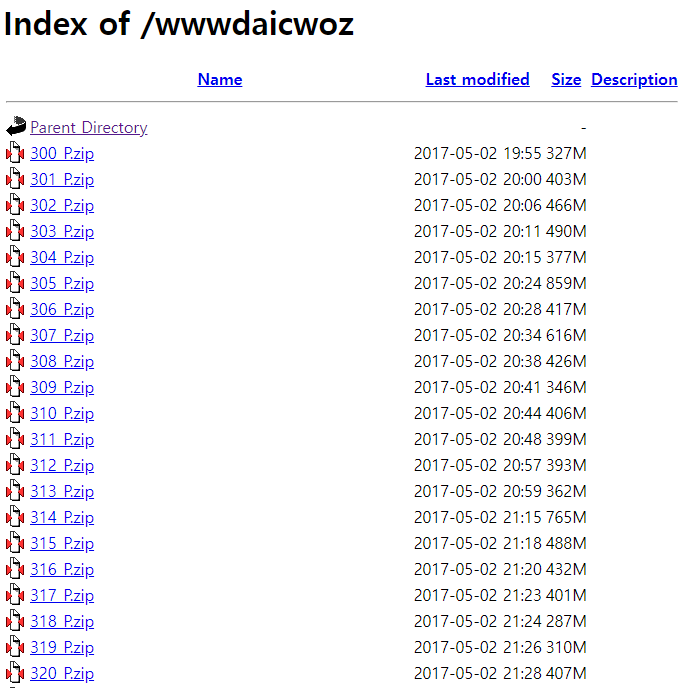

#### 웹페이지 크롤링

In [ ]:
import os
import requests
from bs4 import BeautifulSoup
import urllib.parse

# 베이스 URL 설정
base_url = 'https://dcapswoz.ict.usc.edu/wwwdaicwoz/'

# 파일 저장 디렉토리
download_dir = './downloads'

# 디렉토리가 없으면 생성
if not os.path.exists(download_dir):
    os.makedirs(download_dir)

# 페이지 내용 가져오기
response = requests.get(base_url)
soup = BeautifulSoup(response.text, 'html.parser')

# 파일 링크 찾기 및 다운로드
for link in soup.find_all('a'):
    file_name = link.get('href')
    if file_name and not file_name.endswith('/') and file_name not in ['?C=N;O=D', '?C=M;O=A', '?C=S;O=A', '?C=D;O=A']:  # 디렉토리가 아닌 파일만 다운로드
        file_url = base_url + file_name
        # 유효하지 않은 문자를 제거하여 파일명 생성
        valid_file_name = urllib.parse.unquote(file_name).replace('/', '_').replace('\\', '_')
        file_path = os.path.join(download_dir, valid_file_name)
        with requests.get(file_url, stream=True) as r:
            with open(file_path, 'wb') as f:
                for chunk in r.iter_content(chunk_size=8192):
                    f.write(chunk)
        print(f'{valid_file_name} 다운로드 완료')

print('모든 파일 다운로드 완료')

300_P.zip 다운로드 완료
301_P.zip 다운로드 완료
302_P.zip 다운로드 완료
303_P.zip 다운로드 완료
304_P.zip 다운로드 완료
305_P.zip 다운로드 완료
306_P.zip 다운로드 완료
307_P.zip 다운로드 완료
308_P.zip 다운로드 완료
309_P.zip 다운로드 완료
310_P.zip 다운로드 완료
311_P.zip 다운로드 완료
312_P.zip 다운로드 완료
313_P.zip 다운로드 완료
314_P.zip 다운로드 완료
315_P.zip 다운로드 완료
316_P.zip 다운로드 완료
317_P.zip 다운로드 완료
318_P.zip 다운로드 완료
319_P.zip 다운로드 완료
320_P.zip 다운로드 완료
321_P.zip 다운로드 완료
322_P.zip 다운로드 완료
323_P.zip 다운로드 완료
324_P.zip 다운로드 완료
325_P.zip 다운로드 완료
326_P.zip 다운로드 완료
327_P.zip 다운로드 완료
328_P.zip 다운로드 완료
329_P.zip 다운로드 완료
330_P.zip 다운로드 완료
331_P.zip 다운로드 완료
332_P.zip 다운로드 완료
333_P.zip 다운로드 완료
334_P.zip 다운로드 완료
335_P.zip 다운로드 완료
336_P.zip 다운로드 완료
337_P.zip 다운로드 완료
338_P.zip 다운로드 완료
339_P.zip 다운로드 완료
340_P.zip 다운로드 완료
341_P.zip 다운로드 완료
343_P.zip 다운로드 완료
344_P.zip 다운로드 완료
345_P.zip 다운로드 완료
346_P.zip 다운로드 완료
347_P.zip 다운로드 완료
348_P.zip 다운로드 완료
349_P.zip 다운로드 완료
350_P.zip 다운로드 완료
351_P.zip 다운로드 완료
352_P.zip 다운로드 완료
353_P.zip 다운로드 완료
354_P.zip 다운로드 완료
355_P.zip 다운로드 완료
356_P.zip 

#### zip파일 해제, 필요없는 파일 제거

In [ ]:
import os
import zipfile

# 압축 파일이 위치한 디렉토리 경로 설정
zip_files_dir = 'downloads/'
# 압축 해제할 디렉토리 설정 (같은 폴더 사용)
extracted_dir = 'out/'

# 남길 파일 조건
keep_keyword = 'TRANSCRIPT.csv'
keep_extensions = ['.wav']

# 주어진 디렉토리 내 모든 .zip 파일 처리
for zip_file_name in os.listdir(zip_files_dir):
    if zip_file_name.endswith('.zip'):
        zip_file_path = os.path.join(zip_files_dir, zip_file_name)

        # .zip 파일 해제
        with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
            zip_ref.extractall(extracted_dir)
            print(f'{zip_file_name} 해제 완료')

    # 특정 파일만 남기기
    for root, dirs, files in os.walk(extracted_dir):

        for file in files:
            file_path = os.path.join(root, file)
            print(file)
            if not (keep_keyword in file or any(file.lower().endswith(ext) for ext in keep_extensions)):
                os.remove(file_path)
                print(f'{file_path} 제거됨')

print('모든 .zip 파일 처리 완료. feature 폴더 내용 제거 및 TRANSCRIPT.csv와 .wav 파일만 남기고 나머지 파일 제거 완료')

300_P.zip 해제 완료
300_AUDIO.wav
300_CLNF_AUs.txt
out/300_CLNF_AUs.txt 제거됨
300_CLNF_features.txt
out/300_CLNF_features.txt 제거됨
300_CLNF_features3D.txt
out/300_CLNF_features3D.txt 제거됨
300_CLNF_gaze.txt
out/300_CLNF_gaze.txt 제거됨
300_CLNF_hog.txt
out/300_CLNF_hog.txt 제거됨
300_CLNF_pose.txt
out/300_CLNF_pose.txt 제거됨
300_COVAREP.csv
out/300_COVAREP.csv 제거됨
300_FORMANT.csv
out/300_FORMANT.csv 제거됨
300_TRANSCRIPT.csv
301_P.zip 해제 완료
300_AUDIO.wav
300_TRANSCRIPT.csv
301_AUDIO.wav
301_CLNF_AUs.txt
out/301_CLNF_AUs.txt 제거됨
301_CLNF_features.txt
out/301_CLNF_features.txt 제거됨
301_CLNF_features3D.txt
out/301_CLNF_features3D.txt 제거됨
301_CLNF_gaze.txt
out/301_CLNF_gaze.txt 제거됨
301_CLNF_hog.bin
out/301_CLNF_hog.bin 제거됨
301_CLNF_pose.txt
out/301_CLNF_pose.txt 제거됨
301_COVAREP.csv
out/301_COVAREP.csv 제거됨
301_FORMANT.csv
out/301_FORMANT.csv 제거됨
301_TRANSCRIPT.csv
302_P.zip 해제 완료
300_AUDIO.wav
300_TRANSCRIPT.csv
301_AUDIO.wav
301_TRANSCRIPT.csv
302_AUDIO.wav
302_CLNF_AUs.txt
out/302_CLNF_AUs.txt 제거됨
302_CLNF_fe

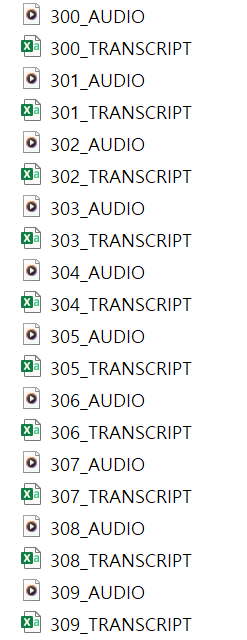

데이터셋은 Ellie라는 애니메이션 가상 면접관이 진행하여 피험자와의 인터뷰를 진행하는형식으로 이루어져 있다.

#### 300_TRANSCRIPT.csv (확장 vs 기본)

In [8]:
import pandas as pd

script_300_확장 = pd.read_csv('./data/300_Transcript_확장.csv')
script_300_확장

,Start_Time,End_Time,Text,Confidence
0,14.3,15.1,so I'm going to,0.934210
1,20.3,21.1,interview in Spanish,0.608470
2,23.9,24.3,okay,0.690606
3,62.1,62.7,good,0.951897
4,68.8,69.8,Atlanta Georgia,0.987629
...,...,...,...,...
72,602.4,603.2,then,0.957885
73,618.0,618.8,thank you,0.989859
74,620.2,620.7,bye-bye,0.622634
75,640.3,643.7,a real life person is really looking at me,0.969585


In [10]:
script_300 = pd.read_csv('./data/300_Transcript.csv')
script_300

,start_time\tstop_time\tspeaker\tvalue
0,36.588\t39.668\tEllie\thi i'm ellie thanks for...
1,39.888\t43.378\tEllie\ti was created to talk t...
2,43.728\t48.498\tEllie\tthink of me as a friend...
3,49.188\t52.388\tEllie\ti'm here to learn about...
4,52.658\t58.958\tEllie\ti'll ask a few question...
...,...
169,610.398\t611.098\tEllie\tokay
170,614.228\t616.878\tEllie\tokay i think i've ask...
171,618.308\t619.078\tParticipant\tthank you
172,619.488\t620.348\tEllie\tgoodbye



script에서 Ellie와 Participant가 구분이 되어있는 기본 DAIC-WOZ 데이터셋을 사용하기로 결정

### 데이터 전처리

#### script파일을 통해 가상의 인터뷰어 Ellie음성, 침묵제거 

'noisereduce' 라이브러리를 통해 노이즈 제거

'pydub' 라이브러리를 통해 구분되어 있는 음성 결합(20초 단위로 구분 -> 데이터의 양이 부족하기에 20초 단위로 구분하여 총 5,067개 음성데이터로 만든다.)
    


In [ ]:
import pandas as pd
from pydub import AudioSegment
import numpy as np
import noisereduce as nr


def process_audio(start_id, end_id, directory):
    for file_id in range(start_id, end_id + 1):
        audio_path = f"{directory}/{file_id}_AUDIO.wav"
        transcript_path = f"{directory}/{file_id}_TRANSCRIPT.csv"

        try:
            # TRANSCRIPT.csv 파일에서 Participant 의 대사만 추출
            transcript = pd.read_csv(transcript_path, sep="\t")
            participant_transcript = transcript[transcript['speaker'] == 'Participant']

            # 오디오 파일 로드
            audio = AudioSegment.from_wav(audio_path)

            # 최종 오디오를 생성할 리스트
            final_audio = AudioSegment.silent(duration=0)

            # 라벨 초기화
            n = 1


            # 대사별 오디오 처리 및 결합
            for index, row in participant_transcript.iterrows():
                start_time = int(row['start_time'] * 1000)  # 시작 시간을 밀리세컨드로 변환
                end_time = int(row['stop_time'] * 1000)  # 종료 시간을 밀리세컨드로 변환
                
                # 잘라낸 오디오
                segment = audio[start_time:end_time]
                
                # 잡음 제거
                segment_np = np.array(segment.get_array_of_samples())
                reduced_noise = nr.reduce_noise(y=segment_np, sr=segment.frame_rate)
                
                # pydub 오디오로 변환
                clean_segment = AudioSegment(
                    data=reduced_noise.tobytes(),
                    sample_width=segment.sample_width,
                    frame_rate=segment.frame_rate,
                    channels=segment.channels
                )
                
                # 결합 전 길이 확인 및 파일 분할
                if len(final_audio) + len(clean_segment) > 20000:  # 20초 초과 시 새 파일 시작
                    final_audio.export(f"./data/reduce/{file_id}_processed_{n}.wav", format="wav")
                    final_audio = clean_segment
                    n += 1
                else:
                    final_audio += clean_segment
            
            # 마지막 파일 저장
            if len(final_audio) > 0:
                final_audio.export(f"./data/reduce/{file_id}_processed_final.wav", format="wav")
                print(f"{file_id}_final 저장완료")
        except Exception as e:
            print(f"Error processing file {file_id}: {e}")


# 함수 실행
process_audio(300, 492, './data/out')


#### 데이터셋 분할
DAIC-WOZ 자체적으로 train, dev, test가 구분되어있다.

train_split_Depression.csv

dev_split_Depression.csv

test_split_Depression.csv

그러나 fine-tuning을 하지 않을 것이기에 dev_split을 구분할 필요가 없다. 


자체적으로 구분되어있는 train_split, test_split을 사용하게 될 경우 test_split에 있는 Participant_ID의 음성은 학습되지 않는다. 

최대한 많은 인원의 음성 데이터를 학습시키기 위하여 자체적으로 구분되어 있는 split을 사용하지 않고,

ID 300부터 399 (총 97명 ID 342, 394, 398는 존재하지 않음)의 processed_1, processed_2 음성 데이터를 test 데이터로 사용한다.

train 폴더 : 4873개 (train_test_split을 통해 trian과 test로 나누어 모델 학습할 것.)

test 폴더 : 194개 (모델 구축 후 검증 과정에서 사용할 test 데이터)

In [41]:
import os
import shutil


# 소스 디렉토리 및 목적지 디렉토리 정의
source_directory = './data/reduce'  # 소스 디렉토리 경로
train_destination_directory = './data/train'  # train 목적지 디렉토리 경로
test_destination_directory = './data/test'    # test 목적지 디렉토리 경로

# 목적지 디렉토리가 존재하지 않으면 생성
os.makedirs(train_destination_directory, exist_ok=True)

# 소스 디렉토리 내 모든 파일 목록 가져오기
all_files = os.listdir(source_directory)

# 파일 이동 로직
for file_name in all_files:
    # 파일 이름이 '1.wav' 또는 '2.wav'로 끝나는지 확인
    if file_name.startswith('3') and (file_name.endswith('_1.wav')) or (file_name.endswith('_2.wav')):
        # 파일 경로 정의
        source_file_path = os.path.join(source_directory, file_name)
        destination_file_path = os.path.join(test_destination_directory, file_name)
        
        # 파일 이동
        shutil.move(source_file_path, destination_file_path)
        print(f"파일 이동: {source_file_path} -> {destination_file_path}")
    else:
        # 파일 경로 정의
        source_file_path = os.path.join(source_directory, file_name)
        destination_file_path = os.path.join(train_destination_directory, file_name)

        # 파일 이동
        shutil.move(source_file_path, destination_file_path)
        print(f"파일 이동: {source_file_path} -> {destination_file_path}")


파일 이동: ./data/reduce\300_processed_1.wav -> ./data/test\300_processed_1.wav
파일 이동: ./data/reduce\300_processed_2.wav -> ./data/test\300_processed_2.wav
파일 이동: ./data/reduce\300_processed_3.wav -> ./data/train\300_processed_3.wav
파일 이동: ./data/reduce\300_processed_4.wav -> ./data/train\300_processed_4.wav
파일 이동: ./data/reduce\300_processed_5.wav -> ./data/train\300_processed_5.wav
파일 이동: ./data/reduce\300_processed_6.wav -> ./data/train\300_processed_6.wav
파일 이동: ./data/reduce\300_processed_7.wav -> ./data/train\300_processed_7.wav
파일 이동: ./data/reduce\300_processed_8.wav -> ./data/train\300_processed_8.wav
파일 이동: ./data/reduce\300_processed_final.wav -> ./data/train\300_processed_final.wav
파일 이동: ./data/reduce\301_processed_1.wav -> ./data/test\301_processed_1.wav
파일 이동: ./data/reduce\301_processed_10.wav -> ./data/train\301_processed_10.wav
파일 이동: ./data/reduce\301_processed_11.wav -> ./data/train\301_processed_11.wav
파일 이동: ./data/reduce\301_processed_12.wav -> ./data/train\301_proce

#### split csv 파일 전처리 (필요한 컬럼 필터, 결합, score 전처리)

In [8]:
# split csv 로드
train_split = pd.read_csv('./split/train_split_Depression.csv')
dev_split = pd.read_csv('./split/dev_split_Depression.csv')
test_split = pd.read_csv('./split/test_split_Depression.csv')
train_split.head()

,Participant_ID,PHQ8_Binary,PHQ8_Score,Gender,PHQ8_NoInterest,PHQ8_Depressed,PHQ8_Sleep,PHQ8_Tired,PHQ8_Appetite,PHQ8_Failure,PHQ8_Concentrating,PHQ8_Moving
0,303,0,0,0,0,0,0.0,0,0,0,0,0
1,304,0,6,0,0,1,1.0,2,2,0,0,0
2,305,0,7,1,0,1,1.0,2,2,1,0,0
3,310,0,4,1,1,1,0.0,0,0,1,1,0
4,312,0,2,1,0,0,1.0,1,0,0,0,0


In [6]:
dev_split.head()

,Participant_ID,PHQ8_Binary,PHQ8_Score,Gender,PHQ8_NoInterest,PHQ8_Depressed,PHQ8_Sleep,PHQ8_Tired,PHQ8_Appetite,PHQ8_Failure,PHQ8_Concentrating,PHQ8_Moving
0,302,0,4,1,1,1,0,1,0,1,0,0
1,307,0,4,0,0,1,0,1,0,2,0,0
2,331,0,8,1,1,1,1,1,1,1,1,1
3,335,1,12,0,1,1,3,2,3,1,1,0
4,346,1,23,0,2,3,3,3,3,3,3,3


In [7]:
test_split.head()

,Participant_ID,PHQ_Binary,PHQ_Score,Gender
0,300,0,2,1
1,301,0,3,1
2,306,0,0,0
3,308,1,22,0
4,309,1,15,1


In [21]:
# 컬럼명 일치
test_split.columns = ['Participant_ID','PHQ8_Binary','PHQ8_Score','Gender']

In [22]:
# 필요 컬럼 외 제거
new_train_split = train_split[['Participant_ID','PHQ8_Binary','PHQ8_Score']]
new_dev_split = dev_split[['Participant_ID','PHQ8_Binary','PHQ8_Score']]
new_test_split = test_split[['Participant_ID','PHQ8_Binary','PHQ8_Score']]

In [30]:
# 하나의 df로 결합
merged_split = pd.concat([new_train_split,new_dev_split,new_test_split], ignore_index=True)
merged_split

,Participant_ID,PHQ8_Binary,PHQ8_Score
0,303,0,0
1,304,0,6
2,305,0,7
3,310,0,4
4,312,0,2
...,...,...,...
184,467,0,0
185,469,0,3
186,470,0,3
187,480,0,1


#### PHQ8-Score를 4단계로 구분
음성데이터가 부족하기 때문에 0부터 24까지의 Score를 예측하기엔 어려움을 가진다. 

따라서 PHQ8_Score를 4단계로 구분한다.

0-4 : 0

5-14 : 1 

15-19 : 2 

19-24 : 4

10부터 우울증으로 판단하기에 0-9를 0, 10-14를 1로 구분하려 하였으나, 0-9를 하나로 묶을 시 절반이상의 data가 하나의 단계로 구분되었다. 

In [33]:
## Score 단계 구분 함수
def convert_phq8_score(score):
    if 0 <= score <= 4:
        return 0
    elif 5 <= score <= 14:
        return 1
    elif 15 <= score <= 19:
        return 2
    elif 19 <= score:
        return 3

# PHQ8_Score 컬럼 변환
merged_split['PHQ8_Score_4'] = merged_split['PHQ8_Score'].apply(convert_phq8_score)

# 변환된 DataFrame 출력
merged_split.head(10)

,Participant_ID,PHQ8_Binary,PHQ8_Score,PHQ8_Score_4
0,303,0,0,0
1,304,0,6,1
2,305,0,7,1
3,310,0,4,0
4,312,0,2,0
5,313,0,7,1
6,315,0,2,0
7,316,0,6,1
8,317,0,8,1
9,318,0,3,0


In [34]:
merged_split['PHQ8_Score_4'].value_counts()

0    86
1    76
2    20
3     7
Name: PHQ8_Score_4, dtype: int64

In [35]:
## Score 단계 구분 함수
def convert_phq8_score(score):
    if 0 <= score <= 4:
        return 0
    elif 5 <= score <= 9:
        return 1
    elif 10 <= score <= 14:
        return 2
    elif 15 <= score <= 19:
        return 3
    elif 19 <= score:
        return 4

# PHQ8_Score 컬럼 변환
merged_split['PHQ8_Score_5'] = merged_split['PHQ8_Score'].apply(convert_phq8_score)

# 변환된 DataFrame 출력
merged_split.head(10)

,Participant_ID,PHQ8_Binary,PHQ8_Score,PHQ8_Score_4,PHQ8_Score_5
0,303,0,0,0,0
1,304,0,6,1,1
2,305,0,7,1,1
3,310,0,4,0,0
4,312,0,2,0,0
5,313,0,7,1,1
6,315,0,2,0,0
7,316,0,6,1,1
8,317,0,8,1,1
9,318,0,3,0,0


In [36]:
merged_split['PHQ8_Score_5'].value_counts()

0    86
1    46
2    30
3    20
4     7
Name: PHQ8_Score_5, dtype: int64

In [42]:
# merged_split 저장
merged_split.to_csv('./split29/split_29.csv', index=False) 

## 우울증 판단 모델 

#### 학습 feature 

우울증 구분 모델에 학습시킬 feature : 

Wav2vec2.0 특징 벡터, Mel-spectrogram, MFCC, Zero-Crossing Rate, RMS Energy


#### Wav2vec2.0

wav 파일을 특징 벡터 및 텍스트로 변환

self-supervised learning을 하기에 labeled 데이터가 부족하여도 높은 정확도를 보임. 

대량의 unlabeled 데이터를 pre-training, 소량의 라벨링된 데이터로 fine-tuning

오픈 소스이기에 다양한 유저가 fine-tuning하여 각 언어 및 상황에 맞는 다양한 모델이 존재.

그 중 base, base-960h, large-xlsr-korean, large-960h, large-xlsr-53-english로 특징 벡터를 추출하여 우울증 판단 모델 학습 후 정확도가 높은 모델 채택 

#### 우울증 판단 모델

우울증 판단 모델로 Logistic Regression, Support Vector Machine(SVM), Gradient Boosting, XGBoost를 비교 후 정확도가 높은 모델 채택 

### PHQ8_Binary 

#### wav 파일에 Binary_label 매핑

In [46]:
import os
import torch
from transformers import Wav2Vec2ForCTC, Wav2Vec2Processor, Trainer, TrainingArguments
import torchaudio


# 장치 설정
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


# 데이터 로드
data = pd.read_csv('./split29/split_29.csv')

# Participant ID와 PHQ8_Binary 컬럼 추출
participant_labels = data[['Participant_ID', 'PHQ8_Binary']].set_index('Participant_ID')

# Participant ID와 wav 파일 매핑
wav_files = {}
wav_directory = './data/train'

for filename in os.listdir(wav_directory):
    if filename.endswith('.wav'):
        participant_id = int(filename.split('_')[0])
        if participant_id in wav_files:
            wav_files[participant_id].append(filename)
        else:
            wav_files[participant_id] = [filename]

for participant_id, files in wav_files.items():
    print(f"Participant {participant_id}: Files: {files}")
    print(f"Label: {participant_labels.loc[participant_id, 'PHQ8_Binary']}")


c:\Users\Jws\AppData\Local\Programs\Python\Python36\lib\site-packages\torchaudio\extension\extension.py:13: UserWarning: torchaudio C++ extension is not available.
  warnings.warn('torchaudio C++ extension is not available.')


Using device: cuda
Participant 300: Files: ['300_processed_3.wav', '300_processed_4.wav', '300_processed_5.wav', '300_processed_6.wav', '300_processed_7.wav', '300_processed_8.wav', '300_processed_final.wav']
Label: 0
Participant 301: Files: ['301_processed_10.wav', '301_processed_11.wav', '301_processed_12.wav', '301_processed_13.wav', '301_processed_14.wav', '301_processed_15.wav', '301_processed_16.wav', '301_processed_17.wav', '301_processed_18.wav', '301_processed_19.wav', '301_processed_20.wav', '301_processed_21.wav', '301_processed_22.wav', '301_processed_23.wav', '301_processed_24.wav', '301_processed_25.wav', '301_processed_26.wav', '301_processed_27.wav', '301_processed_28.wav', '301_processed_29.wav', '301_processed_3.wav', '301_processed_4.wav', '301_processed_5.wav', '301_processed_6.wav', '301_processed_7.wav', '301_processed_8.wav', '301_processed_9.wav', '301_processed_final.wav']
Label: 0
Participant 302: Files: ['302_processed_10.wav', '302_processed_11.wav', '302_pr

#### 데이터셋 생성

In [47]:
## 데이터셋 생성

# 모델과 프로세서 로드
processor = Wav2Vec2Processor.from_pretrained("facebook/wav2vec2-base-960h")
model = Wav2Vec2ForCTC.from_pretrained("facebook/wav2vec2-base-960h").to(device)

def prepare_dataset(batch):
    audio_path = f"./data/train/{batch['audio_filename']}"
    speech_array, sampling_rate = torchaudio.load(audio_path)
    inputs = processor(speech_array.squeeze().numpy(), sampling_rate=sampling_rate, padding=True, return_tensors="pt")
    batch["input_values"] = inputs.input_values.squeeze(0).tolist()  # 텐서를 리스트로 변환
    batch["labels"] = batch["label"]
    return batch

# 데이터셋 생성
data_items = []
for participant_id, files in wav_files.items():
    label = participant_labels.loc[participant_id, 'PHQ8_Binary']
    for file_name in files:
        data_items.append({'audio_filename': file_name, 'label': label})

Some weights of Wav2Vec2ForCTC were not initialized from the model checkpoint at facebook/wav2vec2-base-960h and are newly initialized: ['wav2vec2.masked_spec_embed']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [48]:
label_data = pd.DataFrame(data_items)
label_data

,audio_filename,label
0,300_processed_3.wav,0
1,300_processed_4.wav,0
2,300_processed_5.wav,0
3,300_processed_6.wav,0
4,300_processed_7.wav,0
...,...,...
4868,492_processed_6.wav,0
4869,492_processed_7.wav,0
4870,492_processed_8.wav,0
4871,492_processed_9.wav,0


#### feature 추출 

In [ ]:
from transformers import Wav2Vec2Processor, Wav2Vec2Model
import torch
import torchaudio
import torchaudio.transforms as T
import numpy as np


# 모델 및 프로세서 로드
processor = Wav2Vec2Processor.from_pretrained("facebook/wav2vec2-base-960h")
model = Wav2Vec2Model.from_pretrained("facebook/wav2vec2-base-960h")

def pad_or_truncate(audio, target_length):
    """오디오 데이터를 지정된 길이로 패딩 또는 잘라내기"""
    if audio.size(1) > target_length:
        return audio[:, :target_length]
    elif audio.size(1) < target_length:
        pad_size = target_length - audio.size(1)
        return torch.nn.functional.pad(audio, (0, pad_size), "constant", 0)
    else:
        return audio


def extract_features(audio_path, target_length):
    """오디오 파일에서 특성 추출"""
    # 오디오 파일 로드
    speech_array, sampling_rate = torchaudio.load(audio_path)
    
    
    # 패딩 또는 잘라내기 적용
    speech_array = pad_or_truncate(speech_array, target_length)
    
    # 차원을 (배치, 채널, 샘플) 형식으로 변경
    speech_array = speech_array.unsqueeze(0)
    
    # 음성 특징 백터 추출 (Wav2Vec2)
    inputs = processor(speech_array.squeeze(), sampling_rate=sampling_rate, return_tensors="pt", padding=True)
    with torch.no_grad():
        outputs = model(inputs.input_values)
        wav2vec_features = outputs.last_hidden_state if hasattr(outputs, 'last_hidden_state') else outputs.hidden_states[-1]
    
    # Mel-spectrogram 추출
    mel_spec_transform = T.MelSpectrogram(sample_rate=sampling_rate, n_mels=64)
    mel_spec = mel_spec_transform(speech_array).squeeze().numpy()

    # MFCC 추출
    mfcc_transform = T.MFCC(sample_rate=sampling_rate, n_mfcc=13)
    mfcc = mfcc_transform(speech_array).squeeze().numpy()

    # Zero-Crossing Rate 추출
    zcr_transform = T.ComputeDeltas()
    zcr = (speech_array.squeeze().numpy() > 0).sum() / float(len(speech_array.squeeze().numpy()))

    # RMS Energy 추출
    rms_transform = T.AmplitudeToDB()
    rms = rms_transform(speech_array).squeeze().numpy().mean()

    return wav2vec_features.squeeze().numpy(), mel_spec, mfcc, zcr, rms

def mean_features(features, target_length):
    """특성 벡터를 고정 길이로 리샘플링 또는 패딩"""
    if features.shape[0] > target_length:
        return features[:target_length]
    elif features.shape[0] < target_length:
        pad_size = target_length - features.shape[0]
        return np.pad(features, ((0, pad_size), (0, 0)), mode='constant')
    else:
        return features


# 음성 특성과 라벨 데이터를 결합
X = []
y = []

# 패딩 또는 잘라내기 길이 (예: 1초 길이의 오디오, 16kHz 샘플링 레이트 기준)
target_length = 16000  

# 특징 벡터의 고정 길이
feature_length = 50   

# 오디오 파일 경로의 기본 경로
base_path = "./data/train/"  

for index, row in label_data.iterrows():
    try:
        # 파일 경로 생성
        audio_filename = row['audio_filename']
        audio_path = base_path + audio_filename
        print(audio_path)
        label = row['label']
        
        # 특징 추출
        wav2vec_features, mel_spec, mfcc, zcr, rms = extract_features(audio_path, target_length)
        resampled_features = mean_features(wav2vec_features, feature_length)

        # # 각 특징의 차원 출력 (디버깅용)
        # print("wav2vec_features shape:", wav2vec_features.shape)
        # print("mel_spec shape:", mel_spec.shape)
        # print("mfcc shape:", mfcc.shape)
        # print("zcr:", zcr)
        # print("rms:", rms)
        
        # 다양한 특징을 결합
        combined_features = np.concatenate((resampled_features.mean(axis=0), 
                                            mel_spec.mean(axis=1), 
                                            mfcc.mean(axis=1), 
                                            [zcr], 
                                            [rms]))
        
        # print(combined_features.size)

        X.append(combined_features)
        # print(X)

        y.append(label)
        # print(y)
        
    except Exception as e:
        print(e)
        break

In [ ]:
## 특성 데이터와 라벨 데이터를 데이터프레임으로 변환
df_features = pd.DataFrame(X)
df_label = pd.DataFrame(y)

# CSV 파일로 저장
csv_file_path = "audio_features_base-960h.csv"
df_features.to_csv(csv_file_path, index=False)

print(f"Data saved to {csv_file_path}")
 
csv_file_path2 = 'audio_label_binary_base-960h.csv'
df_label.to_csv(csv_file_path2, index= False)

print(f"Data saved to {csv_file_path2}")

위와 같은 과정으로 base, base-960h, korean, large-960h, xlsr-53-english의 audio_features, audio_label_binary, audio_label_score 파일 저장

### 학습 모델 비교

In [1]:
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import GradientBoostingClassifier
import xgboost as xgb

In [ ]:
# X, y 로드
X = pd.read_csv('./xlsr-53-english/audio_features_xlsr-53-english.csv')
y = pd.read_csv('./xlsr-53-english/audio_label_binary_xlsr-53-english.csv')

# 데이터셋 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 모델 학습 및 초기 정확도 측정
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Support Vector Machine": SVC(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "XGBoost": xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss')
}

accuracies = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    accuracies[name] = accuracy
    print(f"{name} Accuracy: {accuracy * 100:.2f}%")


Logistic Regression Accuracy: 68.65%
Support Vector Machine Accuracy: 69.67%
Gradient Boosting Accuracy: 69.16%
XGBoost Accuracy: 69.88%


결과 표 넣을 것

결과 해석(koran과 base-960h를 사용하기로 결정. XGboost를 사용하기로 결정)

최적의 파라미터 찾기

In [ ]:
# Logistic Regression 파라미터 튜닝
param_grid_lr = {
    'C': [0.1, 1, 10, 100],       # 규제 매개변수, 낮을수록 규제가 강함
    'solver': ['newton-cg', 'lbfgs', 'liblinear']  # 최적화 알고리즘
}

grid_search_lr = GridSearchCV(LogisticRegression(max_iter=1000), param_grid_lr, cv=5, scoring='accuracy')
grid_search_lr.fit(X_train, y_train)
best_log_reg = grid_search_lr.best_estimator_
y_pred_lr = best_log_reg.predict(X_test)

print(f"\nLogistic Regression Best Parameters: {grid_search_lr.best_params_}")
print(f"Logistic Regression Best Cross-validation Accuracy: {grid_search_lr.best_score_*100:.2f}")
print(f"Logistic Regression Test Accuracy: {accuracy_score(y_test, y_pred_lr)*100:.2f}")


Logistic Regression Best Parameters: {'C': 0.1, 'solver': 'lbfgs'}
Logistic Regression Best Cross-validation Accuracy: 68.85
Logistic Regression Test Accuracy: 72.03


In [ ]:
# Support Vector Machine 파라미터 튜닝
param_grid_svm = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['rbf', 'poly', 'sigmoid']
}

grid_search_svm = GridSearchCV(SVC(), param_grid_svm, cv=5, scoring='accuracy')
grid_search_svm.fit(X_train, y_train)
best_svm = grid_search_svm.best_estimator_
y_pred_svm = best_svm.predict(X_test)

print(f"\nSupport Vector Machine Best Parameters: {grid_search_svm.best_params_}")
print(f"Support Vector Machine Best Cross-validation Accuracy: {grid_search_svm.best_score_*100:.2f}")
print(f"Support Vector Machine Test Accuracy: {accuracy_score(y_test, y_pred_svm)*100:.2f}")



Support Vector Machine Best Parameters: {'C': 0.1, 'kernel': 'rbf'}
Support Vector Machine Best Cross-validation Accuracy: 68.70
Support Vector Machine Test Accuracy: 72.03


In [ ]:
# Gradient Boosting 파라미터 튜닝
param_grid_gb = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 4, 5]
}

grid_search_gb = GridSearchCV(GradientBoostingClassifier(), param_grid_gb, cv=5, scoring='accuracy')
grid_search_gb.fit(X_train, y_train)
best_gb = grid_search_gb.best_estimator_
y_pred_gb = best_gb.predict(X_test)

print(f"\nGradient Boosting Best Parameters: {grid_search_gb.best_params_}")
print(f"Gradient Boosting Best Cross-validation Accuracy: {grid_search_gb.best_score_*100:.2f}")
print(f"Gradient Boosting Test Accuracy: {accuracy_score(y_test, y_pred_gb)*100:.2f}")

In [ ]:
# XGBoost 파라미터 튜닝
param_grid_xgb = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 4, 5]
}

grid_search_xgb = GridSearchCV(xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss'), param_grid_xgb, cv=5, scoring='accuracy')
grid_search_xgb.fit(X_train, y_train)
best_xgb = grid_search_xgb.best_estimator_
y_pred_xgb = best_xgb.predict(X_test)

print(f"\nXGBoost Best Parameters: {grid_search_xgb.best_params_}")
print(f"XGBoost Best Cross-validation Accuracy: {grid_search_xgb.best_score_*100:.2f}")
print(f"XGBoost Test Accuracy: {accuracy_score(y_test, y_pred_xgb)*100:.2f}")



XGBoost Best Parameters: {'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 300}
XGBoost Best Cross-validation Accuracy: 68.83
XGBoost Test Accuracy: 72.54


In [ ]:
### 결과 txt파일로 저장하는 코드

import nbformat

# 노트북 파일 경로 지정
notebook_path = '파라미터튜닝(고정).ipynb' # Jupyter Notebook 파일 경로
output_file_path = './txt/xlsr-53-english_binary_outputs.txt' # 출력 내용을 저장할 파일 경로

# 노트북 파일 열기
with open(notebook_path, 'r', encoding='utf-8') as f:
    notebook = nbformat.read(f, as_version=4)

# 모든 셀 출력 수집
outputs = []
for cell in notebook.cells:
    if cell.cell_type == 'code':
        for output in cell.outputs:
            if 'text' in output:
                outputs.append(output['text'])
            elif 'data' in output:
                if 'text/plain' in output['data']:
                    outputs.append(output['data']['text/plain'])

# 출력 내용을 파일에 저장
with open(output_file_path, 'w', encoding='utf-8') as f:
    for output in outputs:
        f.write(output + '\n')


feature로 wav2vec2 특징 벡터만 사용한 것보다 5개 사용한 것이 더 높은 정확도를 보였다. (wav2vec특징 벡터+mel-sepctogram 2개 사용한 것보다 5개 사용한 것이 더 높게 나타남.)

그러나 mel-spectogram만을 사용한 것이 더 높은 정확도를 보였다. (내용 넣을지 말지 고민)

그럼에도 5개의 벡터값들을 사용하는 이유는 wav2vec2는 상황에 맞는 fine-tuning이 가능해 향후 더 높은 정확도를 보일 것으로 기대되기 때문.

### Kfold 교차검증

In [5]:
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score

## base-960h
X = pd.read_csv('./base-960h/audio_features_base-960h.csv')
y = pd.read_csv('./base-960h/audio_label_binary_base-960h.csv')

### 로지스틱 회귀

try:
    # 모델 설정
    model = LogisticRegression(max_iter=1000, C=0.1, solver='newton-cg')

    kf = KFold(n_splits=5,shuffle=True, random_state=42)

    # 교차 검증 수행 (5-폴드)
    scores = cross_val_score(model, X, y, cv=kf, scoring='accuracy')

    # 교차 검증 결과 출력
    print('base-960h 로지스틱 회귀')
    print(f"각 폴드의 정확도: {scores}")
    print(f"평균 정확도: {np.mean(scores)*100:.2f}")
except:
    print('base-960h 로지스틱 회귀 오류')
    pass

### GradientBoosting

try:
    # 모델 설정
    model = GradientBoostingClassifier(learning_rate=0.01, max_depth=3, n_estimators=200)

    kf = KFold(n_splits=5,shuffle=True, random_state=42)

    # 교차 검증 수행 (5-폴드)
    scores = cross_val_score(model, X, y, cv=kf, scoring='accuracy')

    # 교차 검증 결과 출력
    print('base-960h GradientBoosting')
    print(f"각 폴드의 정확도: {scores}")
    print(f"평균 정확도: {np.mean(scores)*100:.2f}")
except:
    print('base-960h GradientBoosting 오류')
    pass

### SVM

try:
    # 모델 설정
    model = SVC(C=0.1, kernel='rbf')

    kf = KFold(n_splits=5,shuffle=True, random_state=42)

    # 교차 검증 수행 (5-폴드)
    scores = cross_val_score(model, X, y, cv=kf, scoring='accuracy')

    # 교차 검증 결과 출력
    print('base-960h SVM')
    print(f"각 폴드의 정확도: {scores}")
    print(f"평균 정확도: {np.mean(scores)*100:.2f}")
except:
    print('base-960h SVM 오류')
    pass

### xgb

try:
    # 모델 설정
    model =  xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', learning_rate = 0.01, max_depth = 5, n_estimators= 300)

    kf = KFold(n_splits=5,shuffle=True, random_state=42)

    # 교차 검증 수행 (5-폴드)
    scores = cross_val_score(model, X, y, cv=kf, scoring='accuracy')

    # 교차 검증 결과 출력
    print('base-960h xgb')
    print(f"각 폴드의 정확도: {scores}")
    print(f"평균 정확도: {np.mean(scores)*100:.2f}")
except:
    print('base-960h xgb 오류')
    pass


######################

## korean
X = pd.read_csv('./korean/audio_features_korean.csv')
y = pd.read_csv('./korean/audio_label_binary_korean.csv')

### 로지스틱 회귀

try:
    # 모델 설정
    model = LogisticRegression(max_iter=1000, C=0.1, solver='newton-cg')

    kf = KFold(n_splits=5,shuffle=True, random_state=42)

    # 교차 검증 수행 (5-폴드)
    scores = cross_val_score(model, X, y, cv=kf, scoring='accuracy')

    # 교차 검증 결과 출력
    print('koeran 로지스틱 회귀')
    print(f"각 폴드의 정확도: {scores}")
    print(f"평균 정확도: {np.mean(scores)*100:.2f}")
except:
    print('koeran 로지스틱 회귀 오류')
    pass

### GradientBoosting

try:
    # 모델 설정
    model = GradientBoostingClassifier(learning_rate=0.01, max_depth=4, n_estimators=200)

    kf = KFold(n_splits=5,shuffle=True, random_state=42)

    # 교차 검증 수행 (5-폴드)
    scores = cross_val_score(model, X, y, cv=kf, scoring='accuracy')

    # 교차 검증 결과 출력
    print('koeran GradientBoosting')
    print(f"각 폴드의 정확도: {scores}")
    print(f"평균 정확도: {np.mean(scores)*100:.2f}")
except:
    print('koeran GradientBoosting 오류')
    pass

### SVM

try:
    # 모델 설정
    model = SVC(C=0.1, kernel='rbf',gamma=1)

    kf = KFold(n_splits=5,shuffle=True, random_state=42)

    # 교차 검증 수행 (5-폴드)
    scores = cross_val_score(model, X, y, cv=kf, scoring='accuracy')

    # 교차 검증 결과 출력
    print('korean SVM')
    print(f"각 폴드의 정확도: {scores}")
    print(f"평균 정확도: {np.mean(scores)*100:.2f}")
except:
    print('korean SVM 오류')
    pass

### xgb

try:
    # 모델 설정
    model =  xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', learning_rate = 0.01, max_depth = 3, n_estimators= 200)

    kf = KFold(n_splits=5,shuffle=True, random_state=42)

    # 교차 검증 수행 (5-폴드)
    scores = cross_val_score(model, X, y, cv=kf, scoring='accuracy')

    # 교차 검증 결과 출력
    print('korean xgb')
    print(f"각 폴드의 정확도: {scores}")
    print(f"평균 정확도: {np.mean(scores)*100:.2f}")
except:
    print('korean xgb 오류')
    pass

FileNotFoundError: [Errno 2] No such file or directory: './base-960h/audio_features_base-960h.csv'

In [ ]:
## base
X = pd.read_csv('./base/audio_features_base.csv')
y = pd.read_csv('./base/audio_label_binary_base.csv')

### 로지스틱 회귀

try:
    # 모델 설정
    model = LogisticRegression(max_iter=1000, C=0.1, solver='newton-cg')

    kf = KFold(n_splits=5,shuffle=True, random_state=42)

    # 교차 검증 수행 (5-폴드)
    scores = cross_val_score(model, X, y, cv=kf, scoring='accuracy')

    # 교차 검증 결과 출력
    print('base 로지스틱 회귀')
    print(f"각 폴드의 정확도: {scores}")
    print(f"평균 정확도: {np.mean(scores)*100:.2f}")
except:
    print('base 로지스틱 회귀 오류')
    pass

### GradientBoosting

try:
    # 모델 설정
    model = GradientBoostingClassifier(learning_rate=0.01, max_depth=4, n_estimators=200)

    kf = KFold(n_splits=5,shuffle=True, random_state=42)

    # 교차 검증 수행 (5-폴드)
    scores = cross_val_score(model, X, y, cv=kf, scoring='accuracy')

    # 교차 검증 결과 출력
    print('base GradientBoosting')
    print(f"각 폴드의 정확도: {scores}")
    print(f"평균 정확도: {np.mean(scores)*100:.2f}")
except:
    print('base GradientBoosting 오류')
    pass

### SVM

try:
    # 모델 설정
    model = SVC(C=0.1, kernel='rbf',gamma=1)

    kf = KFold(n_splits=5,shuffle=True, random_state=42)

    # 교차 검증 수행 (5-폴드)
    scores = cross_val_score(model, X, y, cv=kf, scoring='accuracy')

    # 교차 검증 결과 출력
    print('base SVM')
    print(f"각 폴드의 정확도: {scores}")
    print(f"평균 정확도: {np.mean(scores)*100:.2f}")
except:
    print('base SVM 오류')
    pass

### xgb

try:
    # 모델 설정
    model =  xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', learning_rate = 0.01, max_depth = 3, n_estimators= 200)

    kf = KFold(n_splits=5,shuffle=True, random_state=42)

    # 교차 검증 수행 (5-폴드)
    scores = cross_val_score(model, X, y, cv=kf, scoring='accuracy')

    # 교차 검증 결과 출력
    print('base xgb')
    print(f"각 폴드의 정확도: {scores}")
    print(f"평균 정확도: {np.mean(scores)*100:.2f}")
except:
    print('base xgb 오류')
    pass

base 로지스틱 회귀
각 폴드의 정확도: [0.71516393 0.68135246 0.70081967 0.6875     0.67418033]
평균 정확도: 69.18
base GradientBoosting
각 폴드의 정확도: [0.72848361 0.68545082 0.69569672 0.68545082 0.68954918]
평균 정확도: 69.69
base SVM
각 폴드의 정확도: [0.72028689 0.68237705 0.69262295 0.68545082 0.6875    ]
평균 정확도: 69.36
base xgb
각 폴드의 정확도: [0.72131148 0.68545082 0.69569672 0.6875     0.68852459]
평균 정확도: 69.57


In [ ]:
## xlsr-53-english
X = pd.read_csv('./xlsr-53-english/audio_features_xlsr-53-english.csv')
y = pd.read_csv('./xlsr-53-english/audio_label_binary_xlsr-53-english.csv')

### 로지스틱 회귀

try:
    # 모델 설정
    model = LogisticRegression(max_iter=1000, C=0.1, solver='newton-cg')

    kf = KFold(n_splits=5,shuffle=True, random_state=42)

    # 교차 검증 수행 (5-폴드)
    scores = cross_val_score(model, X, y, cv=kf, scoring='accuracy')

    # 교차 검증 결과 출력
    print('english 로지스틱 회귀')
    print(f"각 폴드의 정확도: {scores}")
    print(f"평균 정확도: {np.mean(scores)*100:.2f}")
except:
    print('english 로지스틱 회귀 오류')
    pass

### GradientBoosting

try:
    # 모델 설정
    model = GradientBoostingClassifier(learning_rate=0.01, max_depth=4, n_estimators=200)

    kf = KFold(n_splits=5,shuffle=True, random_state=42)

    # 교차 검증 수행 (5-폴드)
    scores = cross_val_score(model, X, y, cv=kf, scoring='accuracy')

    # 교차 검증 결과 출력
    print('english GradientBoosting')
    print(f"각 폴드의 정확도: {scores}")
    print(f"평균 정확도: {np.mean(scores)*100:.2f}")
except:
    print('english GradientBoosting 오류')
    pass

### SVM

try:
    # 모델 설정
    model = SVC(C=0.1, kernel='rbf',gamma=1)

    kf = KFold(n_splits=5,shuffle=True, random_state=42)

    # 교차 검증 수행 (5-폴드)
    scores = cross_val_score(model, X, y, cv=kf, scoring='accuracy')

    # 교차 검증 결과 출력
    print('english SVM')
    print(f"각 폴드의 정확도: {scores}")
    print(f"평균 정확도: {np.mean(scores)*100:.2f}")
except:
    print('english SVM 오류')
    pass

### xgb

try:
    # 모델 설정
    model =  xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', learning_rate = 0.01, max_depth = 3, n_estimators= 200)

    kf = KFold(n_splits=5,shuffle=True, random_state=42)

    # 교차 검증 수행 (5-폴드)
    scores = cross_val_score(model, X, y, cv=kf, scoring='accuracy')

    # 교차 검증 결과 출력
    print('english xgb')
    print(f"각 폴드의 정확도: {scores}")
    print(f"평균 정확도: {np.mean(scores)*100:.2f}")
except:
    print('english xgb 오류')
    pass

english 로지스틱 회귀
각 폴드의 정확도: [0.7192623  0.68135246 0.69877049 0.69569672 0.67418033]
평균 정확도: 69.39
english GradientBoosting
각 폴드의 정확도: [0.72336066 0.68442623 0.69979508 0.68647541 0.68647541]
평균 정확도: 69.61
english SVM
각 폴드의 정확도: [0.72028689 0.68237705 0.69262295 0.68545082 0.6875    ]
평균 정확도: 69.36
english xgb
각 폴드의 정확도: [0.72131148 0.68442623 0.69467213 0.68954918 0.68852459]
평균 정확도: 69.57


In [ ]:
## large-960h
X = pd.read_csv('./large-960h/audio_features_large-960h.csv')
y = pd.read_csv('./large-960h/audio_label_binary_large-960h.csv')

### 로지스틱 회귀

try:
    # 모델 설정
    model = LogisticRegression(max_iter=1000, C=0.1, solver='newton-cg')

    kf = KFold(n_splits=5,shuffle=True, random_state=42)

    # 교차 검증 수행 (5-폴드)
    scores = cross_val_score(model, X, y, cv=kf, scoring='accuracy')

    # 교차 검증 결과 출력
    print('large-960h 로지스틱 회귀')
    print(f"각 폴드의 정확도: {scores}")
    print(f"평균 정확도: {np.mean(scores)*100:.2f}")
except:
    print('large-960h 로지스틱 회귀 오류')
    pass

### GradientBoosting

try:
    # 모델 설정
    model = GradientBoostingClassifier(learning_rate=0.01, max_depth=4, n_estimators=200)

    kf = KFold(n_splits=5,shuffle=True, random_state=42)

    # 교차 검증 수행 (5-폴드)
    scores = cross_val_score(model, X, y, cv=kf, scoring='accuracy')

    # 교차 검증 결과 출력
    print('large-960h GradientBoosting')
    print(f"각 폴드의 정확도: {scores}")
    print(f"평균 정확도: {np.mean(scores)*100:.2f}")
except:
    print('large-960h GradientBoosting 오류')
    pass

### SVM

try:
    # 모델 설정
    model = SVC(C=0.1, kernel='rbf',gamma=1)

    kf = KFold(n_splits=5,shuffle=True, random_state=42)

    # 교차 검증 수행 (5-폴드)
    scores = cross_val_score(model, X, y, cv=kf, scoring='accuracy')

    # 교차 검증 결과 출력
    print('large-960h SVM')
    print(f"각 폴드의 정확도: {scores}")
    print(f"평균 정확도: {np.mean(scores)*100:.2f}")
except:
    print('large-960h SVM 오류')
    pass

### xgb

try:
    # 모델 설정
    model =  xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', learning_rate = 0.01, max_depth = 3, n_estimators= 200)

    kf = KFold(n_splits=5,shuffle=True, random_state=42)

    # 교차 검증 수행 (5-폴드)
    scores = cross_val_score(model, X, y, cv=kf, scoring='accuracy')

    # 교차 검증 결과 출력
    print('large-960h xgb')
    print(f"각 폴드의 정확도: {scores}")
    print(f"평균 정확도: {np.mean(scores)*100:.2f}")
except:
    print('large-960h xgb 오류')
    pass

large-960h 로지스틱 회귀
각 폴드의 정확도: [0.70389344 0.66598361 0.68545082 0.6772541  0.65778689]
평균 정확도: 67.81
large-960h GradientBoosting
각 폴드의 정확도: [0.72643443 0.6875     0.69364754 0.6875     0.68852459]
평균 정확도: 69.67
large-960h SVM
각 폴드의 정확도: [0.72028689 0.68237705 0.69262295 0.68545082 0.6875    ]
평균 정확도: 69.36
large-960h xgb
각 폴드의 정확도: [0.72131148 0.68545082 0.69672131 0.68852459 0.68852459]
평균 정확도: 69.61


### 모델 학습



In [3]:
# 필요한 라이브러리 설치 및 불러오기
import pandas as pd
from sklearn.model_selection import train_test_split
import xgboost as xgb
from sklearn.metrics import accuracy_score,mean_absolute_error, mean_squared_error,f1_score, precision_score, recall_score
import joblib
from sklearn.preprocessing import MinMaxScaler

# # 데이터 불러오기
# X = pd.read_csv('./features/base-960h2/audio_features_base-960h2.csv')
# y = pd.read_csv('./features/base-960h2/audio_label_binary_base-960h2.csv')


# 데이터 불러오기
X = pd.read_csv('./features/korean2/audio_features_korean2.csv')
y = pd.read_csv('./features/korean2/audio_label_binary_korean2.csv')

# 데이터셋 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 하이퍼파라미터 설정
params = {
    'n_estimators': 300,
    'learning_rate': 0.01,
    'max_depth': 5
}

# XGBoost 모델 학습
model = xgb.XGBClassifier(**params, use_label_encoder=False, eval_metric='logloss')
model.fit(X_train, y_train)

# 모델 예측
y_pred = model.predict(X_test)

# 성능 지표 
# accuarcy, mae, mse, rmse, f1_score
accuracy = accuracy_score(y_test, y_pred)
# mae = mean_absolute_error(y_test, y_pred)   # 회귀지표이므로 적절하지 않음
# mse = mean_squared_error(y_test, y_pred)    # 회귀지표이므로 적절하지 않음
# rmse = np.sqrt(mse)                         # 회귀지표이므로 적절하지 않음
f1 = f1_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)


# 평가
print(f"Accuracy: {accuracy}")
# print(f"MAE : {mae}")
# print(f'MSE: {mse}')
# print(f'RMSE: {rmse}')
print(f'F1 Score: {f1}')
print(f'Precision: {precision}')
print(f'Recall: {recall}')

# # 모델 저장
# model_filename = './모델/base-960h2_XGB.pkl'
# joblib.dump(model, model_filename)


Accuracy: 0.6974358974358974
F1 Score: 0.0694006309148265
Precision: 0.8461538461538461
Recall: 0.03618421052631579


In [7]:
# 필요한 라이브러리 설치 및 불러오기
import pandas as pd
from sklearn.model_selection import train_test_split
import xgboost as xgb
from sklearn.metrics import accuracy_score,mean_absolute_error, mean_squared_error,f1_score, precision_score, recall_score
import joblib
from sklearn.preprocessing import MinMaxScaler

# 데이터 불러오기
X = pd.read_csv('./features/base-960h2/audio_features_base-960h2.csv')
y = pd.read_csv('./features/base-960h2/audio_label_binary_base-960h2.csv')


# 데이터셋 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 하이퍼파라미터 설정
params = {
    'n_estimators': 300,
    'learning_rate': 0.01,
    'max_depth': 5
}

# XGBoost 모델 학습
model = xgb.XGBClassifier(**params, use_label_encoder=False, eval_metric='logloss')
model.fit(X_train, y_train)

# 모델 예측
y_pred = model.predict(X_test)

# 성능 지표 
# accuarcy, mae, mse, rmse, f1_score
accuracy = accuracy_score(y_test, y_pred)
# mae = mean_absolute_error(y_test, y_pred)   # 회귀지표이므로 적절하지 않음
# mse = mean_squared_error(y_test, y_pred)    # 회귀지표이므로 적절하지 않음
# rmse = np.sqrt(mse)                         # 회귀지표이므로 적절하지 않음
f1 = f1_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)


# 평가
print(f"Accuracy: {accuracy}")
# print(f"MAE : {mae}")
# print(f'MSE: {mse}')
# print(f'RMSE: {rmse}')
print(f'F1 Score: {f1}')
print(f'Precision: {precision}')
print(f'Recall: {recall}')

# # 모델 저장
# model_filename = './모델/base-960h2_XGB.pkl'
# joblib.dump(model, model_filename)


F1 score가 0.069로 매우 낮은 것은

모델이 대부분의 양성 샘플을 음성으로 예측하거나, 많은 음성 샘플을 양성으로 잘못 예측할 가능성이 크다.

데이터셋이 불균형한 경우 (양성 샘플이 적은 경우), F1 스코어가 낮아질 수 있다. 이런 상황에서 오버샘플링이나 언더샘플링으로 추가적인 데이터의 불균형을 처리해주어야 한다.

In [8]:
# Wav2Vec2 모델과 프로세서 불러오기
processor = Wav2Vec2Processor.from_pretrained("facebook/wav2vec2-base-960h")
model = Wav2Vec2Model.from_pretrained("facebook/wav2vec2-base-960h")


Some weights of the model checkpoint at facebook/wav2vec2-base-960h were not used when initializing Wav2Vec2Model: ['lm_head.bias', 'lm_head.weight']
- This IS expected if you are initializing Wav2Vec2Model from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing Wav2Vec2Model from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some weights of Wav2Vec2Model were not initialized from the model checkpoint at facebook/wav2vec2-base-960h and are newly initialized: ['wav2vec2.masked_spec_embed']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [9]:
def pad_or_truncate(audio, target_length):
    """오디오 데이터를 지정된 길이로 패딩 또는 잘라내기"""
    if audio.size(1) > target_length:
        return audio[:, :target_length]
    elif audio.size(1) < target_length:
        pad_size = target_length - audio.size(1)
        return torch.nn.functional.pad(audio, (0, pad_size), "constant", 0)
    else:
        return audio

def extract_features(audio_path, target_length):
    """오디오 파일에서 특성 추출"""
    # 오디오 파일 로드
    speech_array, sampling_rate = torchaudio.load(audio_path)
    
    # 패딩 또는 잘라내기 적용
    speech_array = pad_or_truncate(speech_array, target_length)
    
    # 차원을 (배치, 채널, 샘플) 형식으로 변경
    speech_array = speech_array.unsqueeze(0)
    
    # 음성 특성 추출 (Wav2Vec2)
    inputs = processor(speech_array.squeeze(), sampling_rate=sampling_rate, return_tensors="pt", padding=True)
    with torch.no_grad():
        outputs = model(inputs.input_values)
        wav2vec_features = outputs.last_hidden_state if hasattr(outputs, 'last_hidden_state') else outputs.hidden_states[-1]
    
    # Mel-spectrogram 추출
    mel_spec_transform = T.MelSpectrogram(sample_rate=sampling_rate, n_mels=64)
    mel_spec = mel_spec_transform(speech_array).squeeze().numpy()

    # MFCC 추출
    mfcc_transform = T.MFCC(sample_rate=sampling_rate, n_mfcc=13)
    mfcc = mfcc_transform(speech_array).squeeze().numpy()

    # Zero-Crossing Rate 추출
    zcr_transform = T.ComputeDeltas()
    zcr = (speech_array.squeeze().numpy() > 0).sum() / float(len(speech_array.squeeze().numpy()))

    # RMS Energy 추출
    rms_transform = T.AmplitudeToDB()
    rms = rms_transform(speech_array).squeeze().numpy().mean()

    return wav2vec_features.squeeze().numpy(), mel_spec, mfcc, zcr, rms

def mean_features(features, target_length):
    """특성 벡터를 고정 길이로 리샘플링 또는 패딩"""
    if features.shape[0] > target_length:
        return features[:target_length]
    elif features.shape[0] < target_length:
        pad_size = target_length - features.shape[0]
        return np.pad(features, ((0, pad_size), (0, 0)), mode='constant')
    else:
        return features

In [10]:
# 학습된 XGBoost 모델 불러오기
xgboost_model = joblib.load('./모델/base-960h2_XGB.pkl')

In [11]:
# 특징 벡터를 사용하여 우울증 여부를 예측하는 함수 정의
def predict_depression(wav_path):
    
    # 특징 추출
    wav2vec_features, mel_spec, mfcc, zcr, rms = extract_features(wav_path, 16000)
    resampled_features = mean_features(wav2vec_features, 50)

    # 다양한 특징을 결합
    combined_features = np.concatenate((resampled_features.mean(axis=0), 
                                        mel_spec.mean(axis=1), 
                                        mfcc.mean(axis=1), 
                                        [zcr], 
                                        [rms]))
        # Debug: 출력 결합 특징 벡터
    # print(f"combined_features: {combined_features.size}")

    
    # XGBoost 모델을 사용하여 예측
    prediction = xgboost_model.predict(np.expand_dims(combined_features, axis=0))
    
    # 예측 결과 반환 (0: 비우울증, 1: 우울증)
    return prediction


중요 

위에는 reduce3(6명 test로 빼놓은 것)로 해왔는데 test를 아예 예측하지 못하였음. 따라서 새로운 분할 reduce4(1,2 빼놓는 것)으로 해서 아래 과정을 거침.

이에 대한 설명이 필요할 것.

위의 코드도 다시 수정 (전처리 과정부터 다시 고칠 것)

In [12]:
# 정답 데이터 로드
df = pd.read_csv('./split29/split_29.csv')

# 결과를 저장할 딕셔너리 초기화
results = {i: [] for i in range(300, 400)}

In [14]:
# ID 320 (PHQ8_score : 11)
for i in range(1,3):
    result = predict_depression(f'./data/test/320_processed_{i}.wav')
    print(result)

[0]
[1]


In [28]:
# ID 320 (PHQ8_score : 11)
for i in range(3,13):
    result = predict_depression(f'./data/train/320_processed_{i}.wav')
    print(result)

[1]
[1]
[0]
[0]
[0]
[1]
[0]
[0]
[0]
[0]


In [27]:
# ID 343 (PHQ8_score : 9)
for i in range(3,13):
    result = predict_depression(f'./data/train/343_processed_{i}.wav')
    print(result)

[0]
[0]
[0]
[0]
[0]
[0]
[0]
[0]
[0]
[0]


In [22]:
# 예측 실행
for j in range(300, 400):
    for i in range(1, 3):
        try:
            result = predict_depression(f'./data/test/{j}_processed_{i}.wav')
            results[j].append(result)
        except:
            print(f'{j} 처리 중 오류 발생')


342 처리 중 오류 발생
342 처리 중 오류 발생
394 처리 중 오류 발생
394 처리 중 오류 발생
398 처리 중 오류 발생
398 처리 중 오류 발생


In [29]:
# 각 참가자의 최종 예측 결과 결정
final_results = {j: max(results[j]) if results[j] else 0 for j in results}


In [30]:

# 정확도 계산을 위한 데이터프레임 생성
final_df = pd.DataFrame(list(final_results.items()), columns=['Participant_ID', 'Predicted_PHQ8_Binary'])

# 정답 데이터와 예측 결과 병합
merged_df = pd.merge(df, final_df, on='Participant_ID', how='inner')


In [31]:

# 정확도 계산
correct_predictions = sum(merged_df['PHQ8_Binary'] == merged_df['Predicted_PHQ8_Binary'])
total_predictions = len(merged_df) 
accuracy = correct_predictions / total_predictions
# 병합된 결과를 표시
merged_df.head(), accuracy

(   Participant_ID  PHQ8_Binary  PHQ8_Score  PHQ8_Score_4  PHQ8_Score_5  \
 0             303            0           0             0             0   
 1             304            0           6             1             1   
 2             305            0           7             1             1   
 3             310            0           4             0             0   
 4             312            0           2             0             0   
 
   Predicted_PHQ8_Binary  
 0                   [0]  
 1                   [0]  
 2                   [0]  
 3                   [0]  
 4                   [0]  ,
 0.8144329896907216)

In [32]:
merged_df

,Participant_ID,PHQ8_Binary,PHQ8_Score,PHQ8_Score_4,PHQ8_Score_5,Predicted_PHQ8_Binary
0,303,0,0,0,0,[0]
1,304,0,6,1,1,[0]
2,305,0,7,1,1,[0]
3,310,0,4,0,0,[0]
4,312,0,2,0,0,[0]
...,...,...,...,...,...,...
92,378,0,1,0,0,[0]
93,384,1,15,2,3,[0]
94,387,0,2,0,0,[0]
95,396,0,5,1,1,[0]


In [33]:
merged_df['Predicted_PHQ8_Binary'].value_counts()

TypeError: unhashable type: 'numpy.ndarray'

Exception ignored in: 'pandas._libs.index.IndexEngine._call_map_locations'
Traceback (most recent call last):
  File "pandas\_libs\hashtable_class_helper.pxi", line 1709, in pandas._libs.hashtable.PyObjectHashTable.map_locations
TypeError: unhashable type: 'numpy.ndarray'


[0]    77
[1]    20
Name: Predicted_PHQ8_Binary, dtype: int64

In [ ]:
merged_df.to_csv('test_base-960h2.csv')

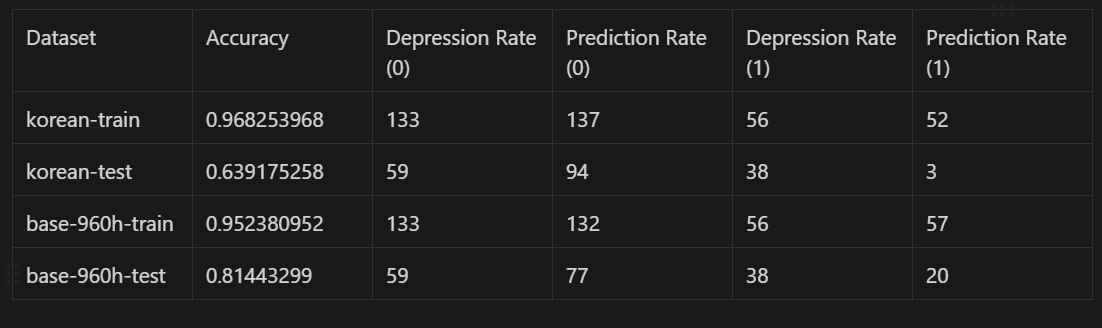

### 예측정확도, 성능지표

#### Korean 예측 정확도

In [ ]:
import pandas as pd
from sklearn.metrics import accuracy_score,f1_score, precision_score, recall_score


In [ ]:
# korea-train

merged_df = pd.read_csv('./예측/train_korean2.csv')

merged_df['Predicted_PHQ8_Binary']  = merged_df['Predicted_PHQ8_Binary'].apply(lambda x: x.strip('[]')).astype(int)

accuracy = accuracy_score(merged_df['PHQ8_Binary'], merged_df['Predicted_PHQ8_Binary'])
f1 = f1_score(merged_df['PHQ8_Binary'], merged_df['Predicted_PHQ8_Binary'])
precision = precision_score(merged_df['PHQ8_Binary'], merged_df['Predicted_PHQ8_Binary'])
recall = recall_score(merged_df['PHQ8_Binary'], merged_df['Predicted_PHQ8_Binary'])

print(f"Accuracy: {accuracy}")
print(f'F1 Score: {f1}')
print(f'Precision: {precision}')
print(f'Recall: {recall}')

Accuracy: 0.9682539682539683
F1 Score: 0.9444444444444444
Precision: 0.9807692307692307
Recall: 0.9107142857142857


In [ ]:
# korea-test

merged_df = pd.read_csv('./예측/test_korean2.csv')

merged_df['Predicted_PHQ8_Binary']  = merged_df['Predicted_PHQ8_Binary'].apply(lambda x: x.strip('[]')).astype(int)

accuracy = accuracy_score(merged_df['PHQ8_Binary'], merged_df['Predicted_PHQ8_Binary'])
f1 = f1_score(merged_df['PHQ8_Binary'], merged_df['Predicted_PHQ8_Binary'])
precision = precision_score(merged_df['PHQ8_Binary'], merged_df['Predicted_PHQ8_Binary'])
recall = recall_score(merged_df['PHQ8_Binary'], merged_df['Predicted_PHQ8_Binary'])

print(f"Accuracy: {accuracy}")
print(f'F1 Score: {f1}')
print(f'Precision: {precision}')
print(f'Recall: {recall}')

### base-960h 예측 정확도

In [ ]:
# base-960h-train

merged_df = pd.read_csv('./예측/train_base-960h2.csv')

merged_df['Predicted_PHQ8_Binary']  = merged_df['Predicted_PHQ8_Binary'].apply(lambda x: x.strip('[]')).astype(int)

accuracy = accuracy_score(merged_df['PHQ8_Binary'], merged_df['Predicted_PHQ8_Binary'])
f1 = f1_score(merged_df['PHQ8_Binary'], merged_df['Predicted_PHQ8_Binary'])
precision = precision_score(merged_df['PHQ8_Binary'], merged_df['Predicted_PHQ8_Binary'])
recall = recall_score(merged_df['PHQ8_Binary'], merged_df['Predicted_PHQ8_Binary'])

print(f"Accuracy: {accuracy}")
print(f'F1 Score: {f1}')
print(f'Precision: {precision}')
print(f'Recall: {recall}')

Accuracy: 0.9523809523809523
F1 Score: 0.9203539823008849
Precision: 0.9122807017543859
Recall: 0.9285714285714286


In [ ]:
# base-960h-test

merged_df = pd.read_csv('./예측/test_base-960h2.csv')

merged_df['Predicted_PHQ8_Binary']  = merged_df['Predicted_PHQ8_Binary'].apply(lambda x: x.strip('[]')).astype(int)

accuracy = accuracy_score(merged_df['PHQ8_Binary'], merged_df['Predicted_PHQ8_Binary'])
f1 = f1_score(merged_df['PHQ8_Binary'], merged_df['Predicted_PHQ8_Binary'])
precision = precision_score(merged_df['PHQ8_Binary'], merged_df['Predicted_PHQ8_Binary'])
recall = recall_score(merged_df['PHQ8_Binary'], merged_df['Predicted_PHQ8_Binary'])

print(f"Accuracy: {accuracy}")
print(f'F1 Score: {f1}')
print(f'Precision: {precision}')
print(f'Recall: {recall}')

Accuracy: 0.8144329896907216
F1 Score: 0.6896551724137931
Precision: 1.0
Recall: 0.5263157894736842
